# Flight Price Prediction

## Dataset Description

The objective of this project is to predict airline ticket prices based on features such as airline, source, destination, class, duration, number of stops, and days left before departure. This is a supervised regression problem.

## Import Libraries

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/sample_submission.csv
/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/train.csv
/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/test.csv


## Load Dataset

In [3]:
train = pd.read_csv("/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/train.csv")
test = pd.read_csv("/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/test.csv")

## Exploratory Data Analysis (Identify data types & Descriptive Statistics)

In [4]:
train.head()
train.shape
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      35387 non-null  object 
 2   flight       40000 non-null  object 
 3   source       40000 non-null  object 
 4   departure    35208 non-null  object 
 5   stops        37681 non-null  object 
 6   arrival      40000 non-null  object 
 7   destination  40000 non-null  object 
 8   class        40000 non-null  object 
 9   duration     36987 non-null  float64
 10  days_left    35562 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.7+ MB


,id,duration,days_left,price
count,40000.00000,36987.000000,35562.000000,40000.00000
mean,19999.50000,12.004088,26.197936,20801.49025
std,11547.14972,7.108063,13.469232,22729.14842
min,0.00000,0.830000,1.000000,1105.00000
25%,9999.75000,6.670000,15.000000,4687.00000
50%,19999.50000,11.080000,26.000000,7353.00000
75%,29999.25000,15.920000,38.000000,42521.00000
max,39999.00000,47.080000,49.000000,114704.00000


### Descriptive Statistics of Numerical Features
The descriptive statistics show the minimum, maximum, mean, median (50th percentile), and standard deviation of the numerical features. The flight prices exhibit a wide range, indicating significant variability in ticket costs. Similarly, the duration of flights varies considerably depending on the route and number of stops.

## Identifying Missing Value

In [5]:
train.isnull().sum()

id                0
airline        4613
flight            0
source            0
departure      4792
stops          2319
arrival           0
destination       0
class             0
duration       3013
days_left      4438
price             0
dtype: int64

## Handling Missing Values

In [6]:
#Categorical columns
cat_cols = ["airline", "departure", "stops"]

for col in cat_cols:
    train[col] = train[col].fillna(train[col].mode()[0])

#Numerical columns
num_cols = ["duration", "days_left"]

for col in num_cols:
    train[col] = train[col].fillna(train[col].median())

train.isnull().sum()

id             0
airline        0
flight         0
source         0
departure      0
stops          0
arrival        0
destination    0
class          0
duration       0
days_left      0
price          0
dtype: int64

## Duplicate Value Handling (Identify and handle duplicate values)

In [7]:
print(train.duplicated().sum())


0


No duplicate rows were found.

## Outlier Analysis (Identify and Handle Outliers)

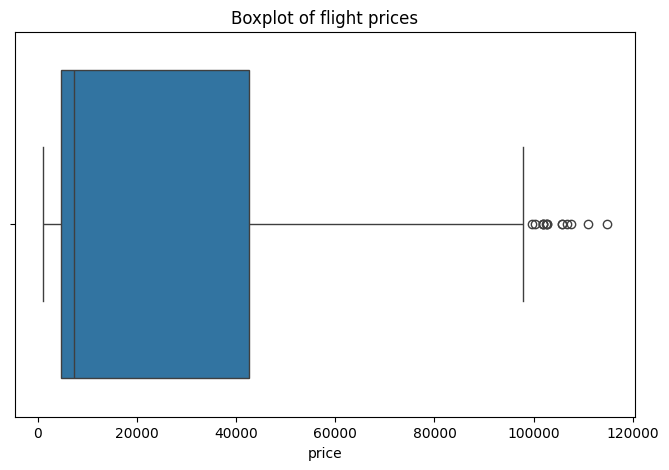

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x=train["price"])
plt.title("Boxplot of flight prices")
plt.show()

**Outlier Analysis:** A box plot of the price column shows a few high-priced observations beyond the upper whiskers. Since these values are realistic for airline ticket prices and may represent premium or last-minute bookings, they were retained than removed.

## Data Visualization (Present at least three visualizations and provide insights for the same)

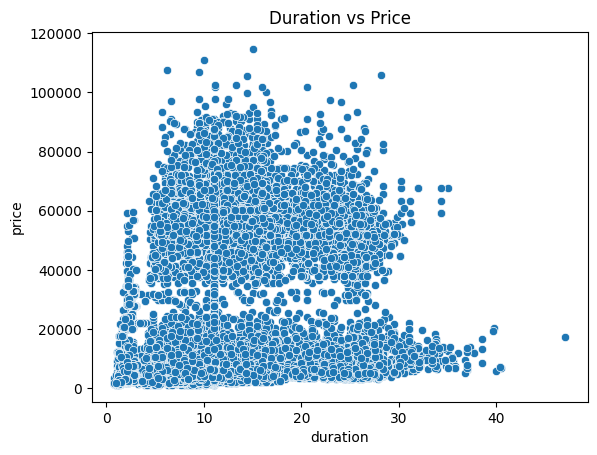

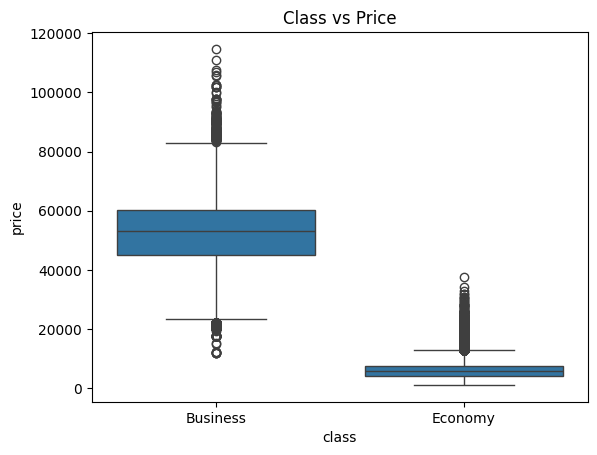

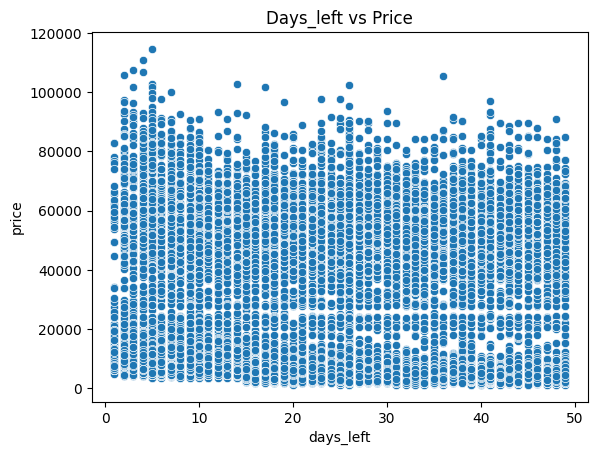

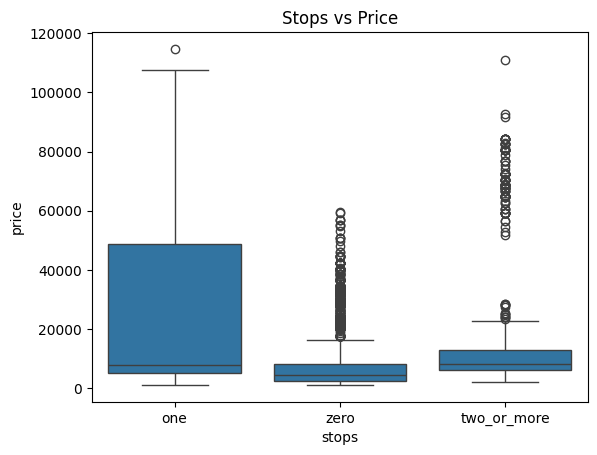

In [9]:
sns.scatterplot(x="duration", y="price", data=train)
plt.title("Duration vs Price")
plt.show()

sns.boxplot(x="class", y="price", data=train)
plt.title("Class vs Price")
plt.show()

sns.scatterplot(x="days_left", y="price", data=train)
plt.title("Days_left vs Price")
plt.show()

sns.boxplot(x="stops", y="price", data=train)
plt.title("Stops vs Price")
plt.show()

### Insights

**1. Duration vs Price (Scatter Plot):**
   The scatter plot shows that flight duration has a weak positive relationship with ticket price. Flights with similar durations can have significantly different prices, indicating that other features such as airline, class, and booking time also influence ticket prices.

**2. Class vs Price (Box Plot):**
   Business class tickets are significantly more expensive than Economy class tickets. The median ticket price for Business class is substantially higher, making the seat class one of the strongest predictors of ticket price.

**3. Days Left vs Price (Scatter Plot):**
   The scatter plot does not show a strong linear relationship between the number of days left and ticket price. This suggests that booking time alone does not determine the ticket price, and other factors such as class, airline, and route also contribute significantly.

**4. Stops vs Price (Box Plot):**
   Ticket prices vary across different stop categories. Flights with one stop exhibit greater variability in prices, while non-stop flights are generally concentrated in a lower price range in this dataset

## Feature Selection and Data Splitting

The input features (X) and target variable (y) were separated. The dataset was then split into training (80%) and validation (20%) sets using `train_test_split()`. Finally, the categorical and numerical features were identified to enable appropriate preprocessing, including encoding categorical variables and scaling numerical variables.

In [10]:
x = train.drop(["id", "price"], axis =1)
y = train["price"]

from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

cat_cols = x.select_dtypes(include=["object"]).columns
num_cols = x.select_dtypes(exclude=["object"]).columns

print(cat_cols)
print(num_cols)

Index(['airline', 'flight', 'source', 'departure', 'stops', 'arrival',
       'destination', 'class'],
      dtype='object')
Index(['duration', 'days_left'], dtype='object')


## Feature Scaling and Encoding (Scale Numerical features and Encode Categorical features)

Machine learning algorithms require numerical input. Therefore, categorical features such as airline, source, destination, class, departure, arrival, flight, and stops were encoded using One-Hot Encoding.

The numerical features (duration and days_left) were standardized using StandardScaler to bring them onto a similar scale. Scaling helps models such as Linear Regression, Ridge, and Lasso perform more effectively. Although tree-based models do not require scaling, a common preprocessing pipeline was used for all models to maintain consistency.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])


## Model Building (At least 7)

### 1. Linear Regression Model

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model= Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])
lr_model.fit(x_train, y_train) #Train the model

y_pred = lr_model.predict(x_val) #make predictions for the validation data

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("Linear Regression:")

print("Mean Absolute Error: ", mae)
print("Root Mean Squared Error: ", rmse)
print("R² Score: ", r2)

Linear Regression:
Mean Absolute Error:  4419.826117972224
Root Mean Squared Error:  6370.924456835021
R² Score:  0.9213320783183928


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, x_train, x_val, y_train, y_val):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_val)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    return mae, rmse, r2
    

### 2. Ridge Regression

In [14]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

mae, rmse, r2 = evaluate_model(
    ridge_model,
    x_train,
    x_val,
    y_train,
    y_val
)

print("Ridge Regression:")

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Ridge Regression:
Mean Absolute Error: 4403.8616548072005
Root Mean Squared Error: 6360.400620725595
R² Score: 0.9215917594824686


### 3. Lasso Regression

In [15]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso())
])

mae, rmse, r2 = evaluate_model(
    lasso_model,
    x_train,
    x_val,
    y_train,
    y_val
)

print("Lasso Regression:")

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Lasso Regression:
Mean Absolute Error: 4396.003569675386
Root Mean Squared Error: 6384.522150469973
R² Score: 0.9209959123954534


### 4. Decision Tree Regressor

In [16]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

mae, rmse, r2 = evaluate_model(
    decision_tree_model,
    x_train,
    x_val,
    y_train,
    y_val
)

print("Decision Tree Model:")

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Decision Tree Model:
Mean Absolute Error: 1869.2331770833332
Root Mean Squared Error: 4471.669676746972
R² Score: 0.9612446025517447


### 5. Random Forest Regressor

In [17]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

mae, rmse, r2 = evaluate_model(
    random_forest_model,
    x_train,
    x_val,
    y_train,
    y_val
)

print("Random Forest Model:")

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Random Forest Model:
Mean Absolute Error: 1702.878616181232
Root Mean Squared Error: 3508.1749602359882
R² Score: 0.97614632736925


### 6. Gradient Boosting Regressor

In [18]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

mae, rmse, r2 = evaluate_model(
    gb_model,
    x_train,
    x_val,
    y_train,
    y_val
)

print("Gradient Boosting Model:")

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Gradient Boosting Model:
Mean Absolute Error: 3052.9727127176143
Root Mean Squared Error: 5091.644499416282
R² Score: 0.9497531416859422


### 7. Extra Trees Regressor

In [19]:
from sklearn.ensemble import ExtraTreesRegressor

extra_trees_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(random_state=42))
])

mae, rmse, r2 = evaluate_model(
    extra_trees_model,
    x_train,
    x_val,
    y_train,
    y_val
)

print("Extra Trees Model:")

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Extra Trees Model:
Mean Absolute Error: 1680.6267508333335
Root Mean Squared Error: 3738.4209139561362
R² Score: 0.9729124852369582


The three linear models produced similar performance, indicating that the flight price prediction problem contains non-linear relationships that linear models cannot fully capture.

## Model Comparison Before Tuning

In [20]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Extra Trees"
    ],
    "MAE": [
        4419.83,
        4403.86,
        4396.00,
        1869.23,
        1702.88,
        3052.97,
        1680.63
    ],
    "RMSE": [
        6370.92,
        6360.40,
        6384.52,
        4471.67,
        3508.17,
        5091.64,
        3738.42
    ],
    "R2 Score": [
        0.9213,
        0.9216,
        0.9210,
        0.9612,
        0.9761,
        0.9498,
        0.9729
    ]
})

results.sort_values("R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
4,Random Forest,1702.88,3508.17,0.9761
6,Extra Trees,1680.63,3738.42,0.9729
3,Decision Tree,1869.23,4471.67,0.9612
5,Gradient Boosting,3052.97,5091.64,0.9498
1,Ridge Regression,4403.86,6360.40,0.9216
0,Linear Regression,4419.83,6370.92,0.9213
2,Lasso Regression,4396.00,6384.52,0.9210


## Hyperparameter Tuning (Hyperparameter Tuning on any 3 of the models)

Hyperparameter tuning was performed on three tree-based ensemble models: Random Forest Regressor, Extra Trees Regressor, and Gradient Boosting Regressor. These models were selected because ensemble methods often benefit significantly from hyperparameter optimization, and tuning parameters such as the number of estimators, maximum tree depth, and learning rate can improve their predictive performance. RandomizedSearchCV was used to efficiently search for suitable hyperparameter combinations while reducing computational time.

The following three models were selected for hyperparameter tuning:
- Random Forest Regressor
- Extra Trees Regressor
- Gradient Boosting Regressor

### 1. Tuned Random Forest

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])
rf_random = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions={
        "model__n_estimators": [50, 100, 150, 200],
        "model__max_depth": [10, 20, 30, None],
        "model__min_samples_split": [2, 5, 10]
    },
    n_iter=5,         
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

rf_random.fit(x_train, y_train)


best_rf = rf_random.best_estimator_

y_pred = best_rf.predict(x_val)
print("Best Parameters:", rf_random.best_params_)
print("Mean Absolute Error:", mean_absolute_error(y_val, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("R2 Score:", r2_score(y_val, y_pred))

Best Parameters: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__max_depth': None}
Mean Absolute Error: 1704.838665060038
Root Mean Squared Error: 3466.1919868542473
R2 Score: 0.9767138337552231


### 2. Tuned Extra Trees

In [22]:
from sklearn.ensemble import ExtraTreesRegressor

et_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(random_state=42))
])

et_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5]
}
et_random = RandomizedSearchCV(
    estimator=et_pipeline,
    param_distributions=et_params,
    n_iter=2,
    cv=2,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)


et_random.fit(x_train, y_train)
best_et = et_random.best_estimator_

y_pred = best_et.predict(x_val)

print("Mean Absolute Error:", mean_absolute_error(y_val, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("R2 Score:", r2_score(y_val, y_pred))

Mean Absolute Error: 1661.1531727083334
Root Mean Squared Error: 3548.234476486139
R2 Score: 0.9755984514170761


### 3. Tuned Gradient Boosting

In [23]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_params = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 5, 7]
}

gb_random = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_params,
    n_iter=2,
    cv=2,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

gb_random.fit(x_train, y_train)


best_gb = gb_random.best_estimator_

y_pred = best_gb.predict(x_val)
print("Best Parameters:", gb_random.best_params_)
print("Mean Absolute Error:", mean_absolute_error(y_val, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("R² Score:", r2_score(y_val, y_pred))

Best Parameters: {'model__n_estimators': 50, 'model__max_depth': 5, 'model__learning_rate': 0.2}
Mean Absolute Error: 2687.878881608062
Root Mean Squared Error: 4540.634425291076
R² Score: 0.9600399667658293


### Summary of results
Seven regression models were trained and evaluated for flight price prediction. Among the linear models, Ridge Regression slightly outperformed Linear Regression and Lasso Regression. Tree-based models performed significantly better than linear models, indicating that the dataset contains complex, non-linear relationships. Random Forest achieved the best overall performance with an R² score of 0.9761 before tuning. Hyperparameter tuning was performed on Random Forest, Extra Trees, and Gradient Boosting using RandomizedSearchCV. After tuning, the Random Forest model achieved the highest R² score of 0.9767 and the lowest RMSE, making it the final model selected for generating predictions on the test dataset.

## Model Comparison After Tuning

In [24]:
tuned_results = pd.DataFrame({
    "Model": [
        "Random Forest (Tuned)",
        "Extra Trees (Tuned)",
        "Gradient Boosting (Tuned)"
    ],
    "MAE": [
        1704.84,
        1661.15,
        2687.88
    ],
    "RMSE": [
        3466.19,
        3548.23,
        4540.63
    ],
    "R² Score": [
        0.9767,
        0.9756,
        0.9600
    ]
})

tuned_results = tuned_results.sort_values(by="R² Score", ascending=False)

tuned_results

,Model,MAE,RMSE,R² Score
0,Random Forest (Tuned),1704.84,3466.19,0.9767
1,Extra Trees (Tuned),1661.15,3548.23,0.9756
2,Gradient Boosting (Tuned),2687.88,4540.63,0.9600


## Final Model Selection and Kaggle Submission

Among all the trained models, the tuned Random Forest Regressor achieved the highest R² score and the lowest RMSE. Therefore, it was selected as the final model for predicting prices on the test dataset.

In [25]:
best_model = rf_random.best_estimator_
best_model.fit(x, y)
x_test = test.drop("id", axis=1)
predictions = best_model.predict(x_test)



In [26]:
submission = pd.DataFrame({
    "id": test["id"],
    "price": predictions
})

submission.to_csv("submission.csv", index=False)

In [27]:
submission.head()

,id,price
0,0,4523.080000
1,1,12417.793301
2,2,3780.734526
3,3,59884.126603
4,4,49786.120117
